In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()
# https://archive.ics.uci.edu/dataset/468/online+shoppers+purchasing+intention+dataset

Saving online_shoppers_intention.csv to online_shoppers_intention.csv


In [4]:
df = pd.read_csv("online_shoppers_intention.csv")
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [6]:
df['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


### Exploratory Data Analysis


In [7]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


User Engagement & Friction

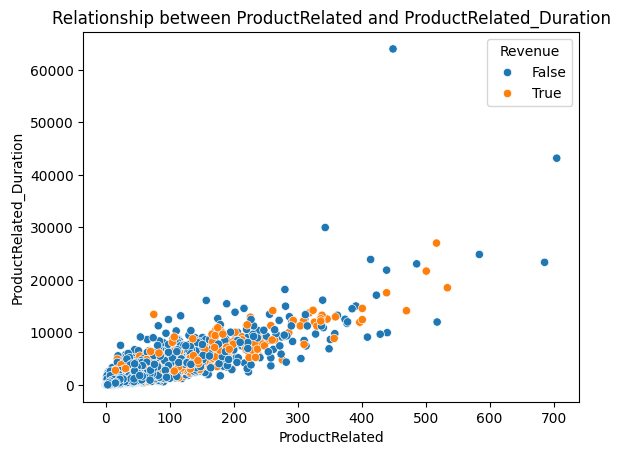

In [8]:
sns.scatterplot(x='ProductRelated', y='ProductRelated_Duration', hue='Revenue', data=df)
plt.title('Relationship between ProductRelated and ProductRelated_Duration')
plt.xlabel('ProductRelated')
plt.ylabel('ProductRelated_Duration')
plt.show()

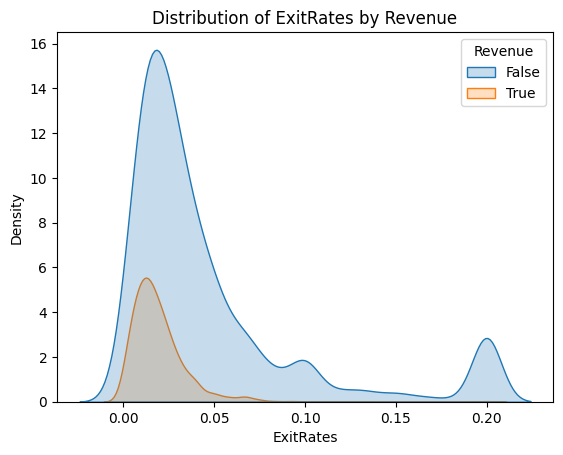

In [9]:
sns.kdeplot(data=df, x='ExitRates', hue='Revenue', fill=True)
plt.title('Distribution of ExitRates by Revenue')
plt.xlabel('ExitRates')
plt.ylabel('Density')
plt.show()

2. Pillar: The "PageValue" Factor

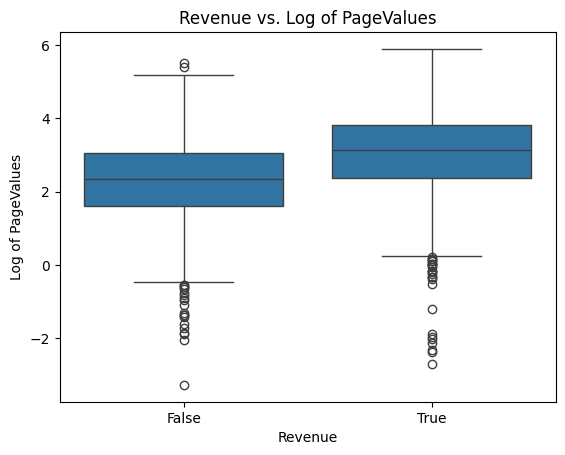

In [10]:
sns.boxplot(x='Revenue', y= np.log(df['PageValues']), data=df)
plt.title('Revenue vs. Log of PageValues')
plt.xlabel('Revenue')
plt.ylabel('Log of PageValues')
plt.show()

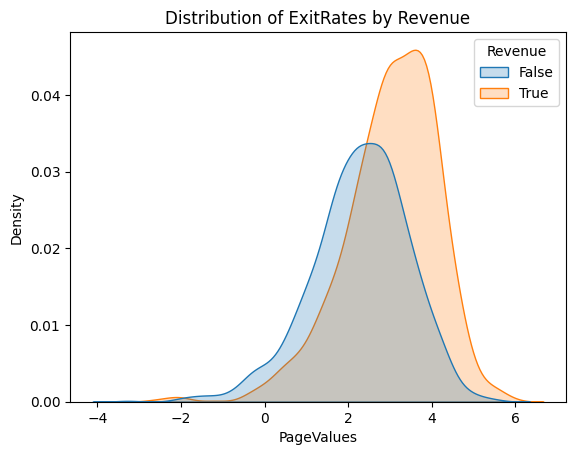

In [11]:
sns.kdeplot(data=df, x=np.log(df['PageValues']), hue='Revenue', fill=True)
plt.title('Distribution of ExitRates by Revenue')
plt.xlabel('PageValues')
plt.ylabel('Density')
plt.show()

Correlation Matrix:
             PageValues  BounceRates  ExitRates   Revenue
PageValues     1.000000    -0.119386  -0.174498  0.492569
BounceRates   -0.119386     1.000000   0.913004 -0.150673
ExitRates     -0.174498     0.913004   1.000000 -0.207071
Revenue        0.492569    -0.150673  -0.207071  1.000000

--- Leakage Analysis ---
Total Buyers: 1908
Buyers with 0 PageValue: 370 (19.39%)
Non-Buyers with >0 PageValue: 1192


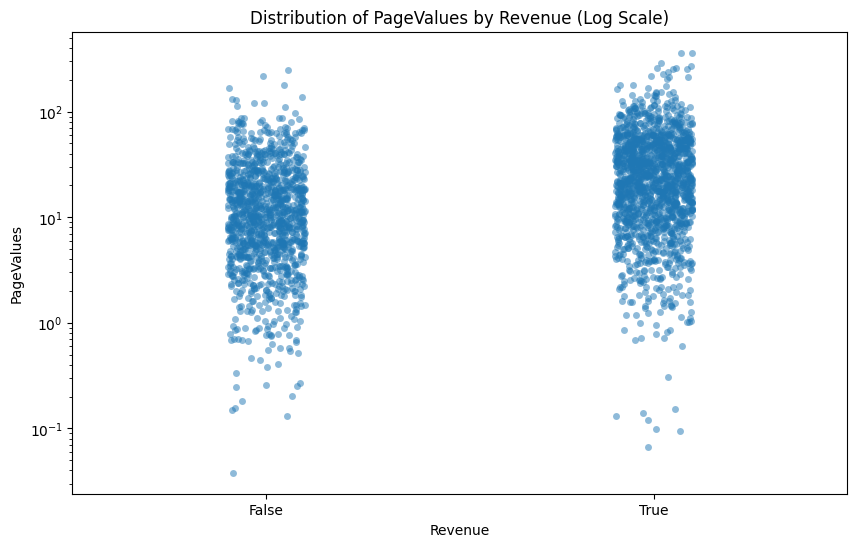

In [12]:
# 1. Basic Correlation Check
cols_to_check = ['PageValues', 'BounceRates', 'ExitRates', 'Revenue']
correlation_matrix = df[cols_to_check].corr()
print("Correlation Matrix:")
print(correlation_matrix)

# 2. The "Zero-Value" Logic Check
# How many people bought SOMETHING without having a PageValue?
total_buyers = df[df['Revenue'] == True].shape[0]
buyers_zero_pagevalue = df[(df['Revenue'] == True) & (df['PageValues'] == 0)].shape[0]
percent_zero_val_buyers = (buyers_zero_pagevalue / total_buyers) * 100

# How many people had a PageValue but DID NOT buy?
non_buyers_with_value = df[(df['Revenue'] == False) & (df['PageValues'] > 0)].shape[0]

print(f"\n--- Leakage Analysis ---")
print(f"Total Buyers: {total_buyers}")
print(f"Buyers with 0 PageValue: {buyers_zero_pagevalue} ({percent_zero_val_buyers:.2f}%)")
print(f"Non-Buyers with >0 PageValue: {non_buyers_with_value}")

# 3. Visualizing the "Conversion Zone"
plt.figure(figsize=(10, 6))
sns.stripplot(x='Revenue', y='PageValues', data=df, jitter=True, alpha=0.5)
plt.yscale('log') # Use log scale because PageValues are highly skewed
plt.title('Distribution of PageValues by Revenue (Log Scale)')
plt.show()

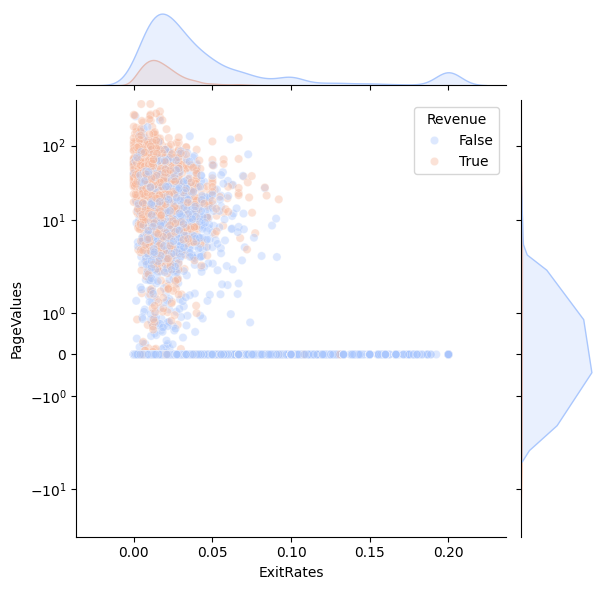

In [13]:
# Create a plot to show the "Conversion Zone"
g = sns.JointGrid(data=df, x="ExitRates", y="PageValues", hue="Revenue", palette='coolwarm')
g.plot_joint(sns.scatterplot, alpha=0.4)
g.plot_marginals(sns.kdeplot, fill=True)
plt.yscale('symlog') # Handles the 0 values while showing the spread of high values
plt.show()

Text(0.5, 1.0, 'Distribution of PageValues by Revenue')

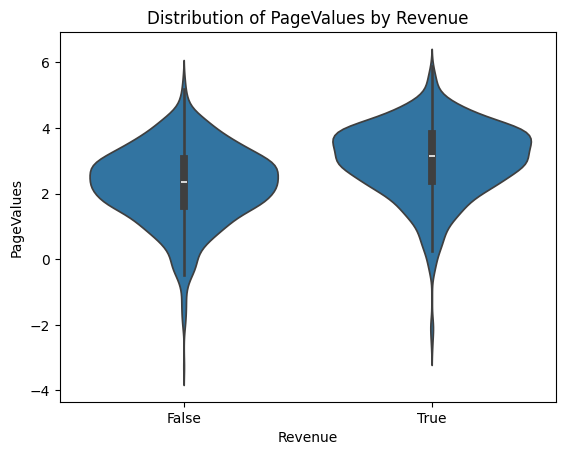

In [14]:
sns.violinplot(x='Revenue', y=np.log(df['PageValues']), data=df)
plt.title('Distribution of PageValues by Revenue')

,PageValue_Binary,Conversion_Rate
0,0,0.038542
1,> 0,0.563370


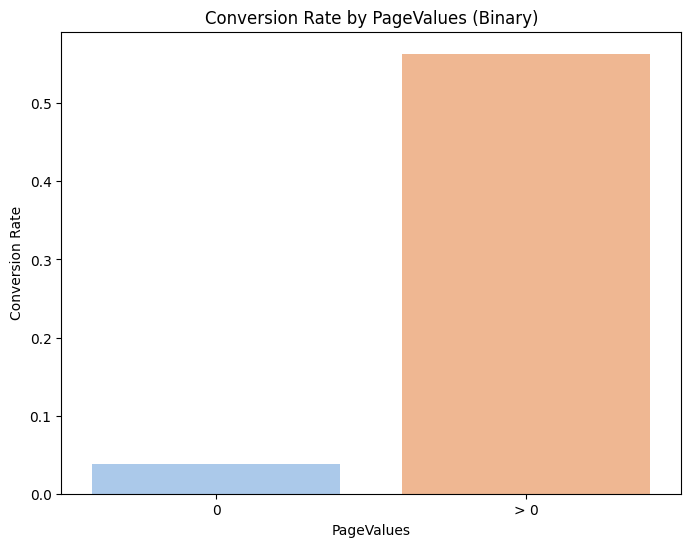

In [15]:
df['PageValue_Binary'] = df['PageValues'].apply(lambda x: '> 0' if x > 0 else '0')

conversion_rate_pagevalue = df.groupby('PageValue_Binary')['Revenue'].mean().reset_index()
conversion_rate_pagevalue.rename(columns={'Revenue': 'Conversion_Rate'}, inplace=True)

display(conversion_rate_pagevalue)

plt.figure(figsize=(8, 6))
sns.barplot(x='PageValue_Binary', y='Conversion_Rate', data=conversion_rate_pagevalue, palette='pastel')
plt.title('Conversion Rate by PageValues (Binary)')
plt.xlabel('PageValues')
plt.ylabel('Conversion Rate')
plt.show()

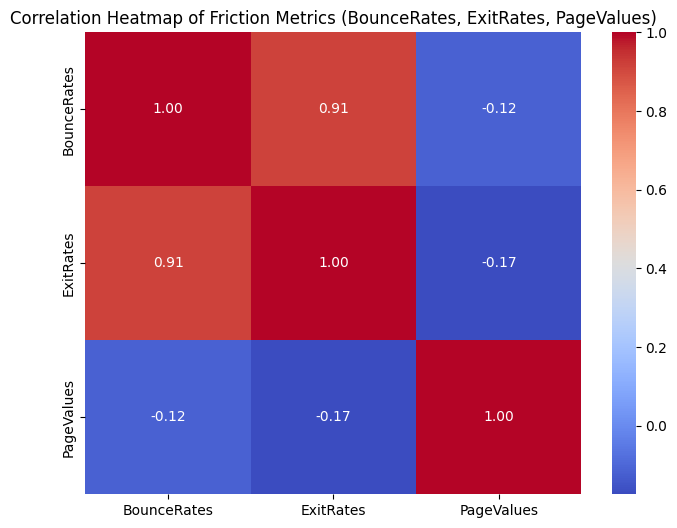

In [16]:
friction_metrics = df[['BounceRates', 'ExitRates', 'PageValues']]
correlation_matrix = friction_metrics.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Friction Metrics (BounceRates, ExitRates, PageValues)')
plt.show()

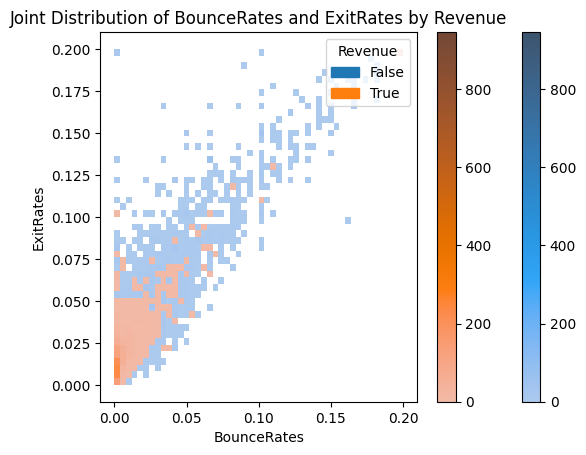

In [17]:
sns.histplot(data=df, x='BounceRates', y='ExitRates', hue='Revenue', bins=50, cbar=True)
plt.title('Joint Distribution of BounceRates and ExitRates by Revenue')
plt.xlabel('BounceRates')
plt.ylabel('ExitRates')
plt.show()

3. Pillar: Behavioral Personas

Text(0.5, 1.0, 'ProductRelated vs. VisitorType')

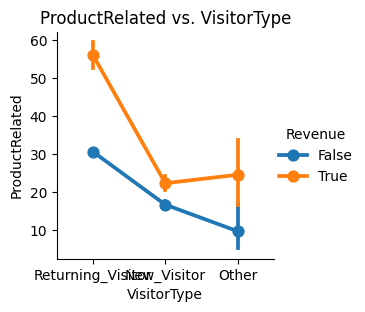

In [18]:
sns.FacetGrid(df, hue='Revenue', ).map(sns.pointplot, 'VisitorType', 'ProductRelated').add_legend()
plt.title('ProductRelated vs. VisitorType')

4. Pillar: Temporal & External Context

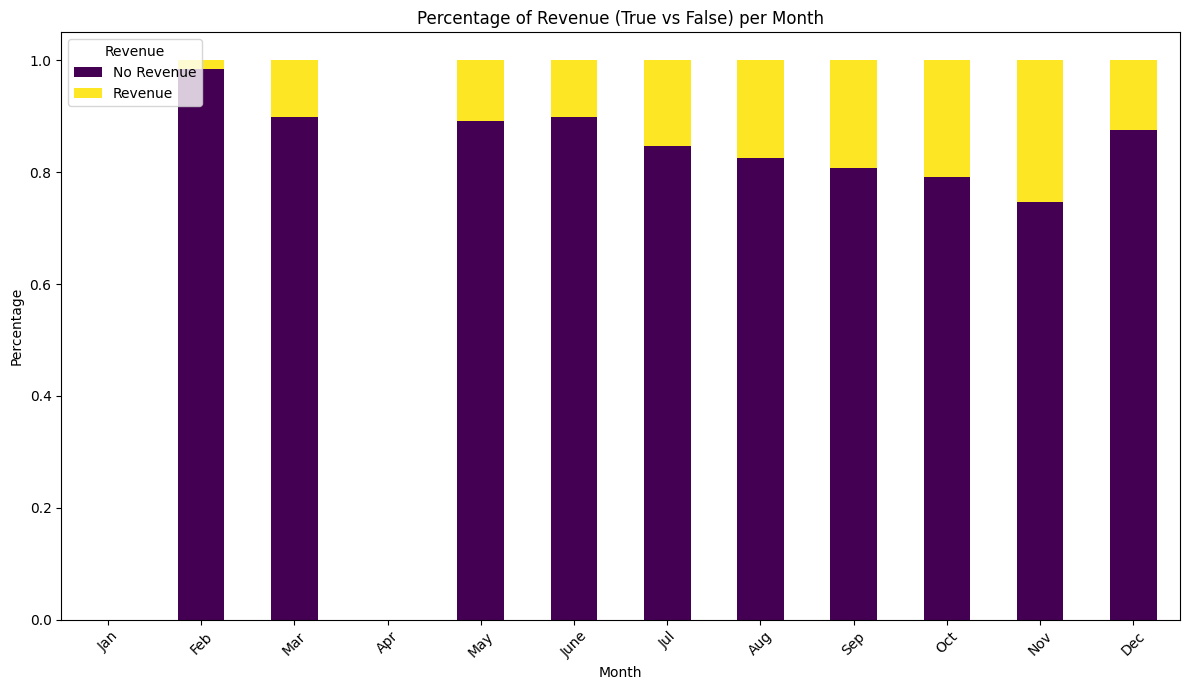

In [19]:
monthly_revenue = df.groupby(['Month', 'Revenue']).size().unstack(fill_value=0)
monthly_revenue_percentage = monthly_revenue.apply(lambda x: x / x.sum(), axis=1)

# Reorder months for better visualization
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue_percentage = monthly_revenue_percentage.reindex(month_order)

monthly_revenue_percentage.plot(kind='bar', stacked=True, figsize=(12, 7), cmap='viridis')
plt.title('Percentage of Revenue (True vs False) per Month')
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.xticks(rotation=45)
plt.legend(title='Revenue', loc='upper left', labels=['No Revenue', 'Revenue'])
plt.tight_layout()
plt.show()

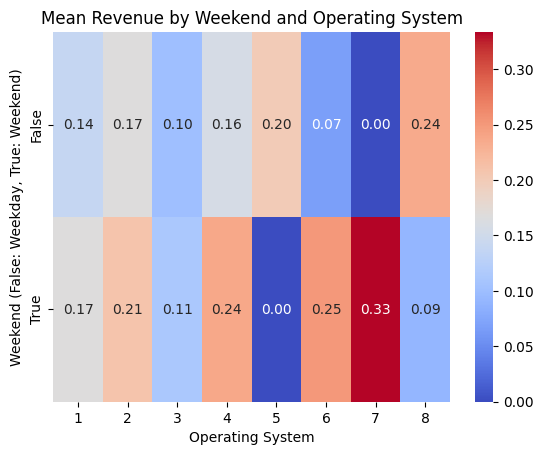

In [20]:
heatmap_data = df.groupby(['Weekend', 'OperatingSystems'])['Revenue'].mean().unstack()
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mean Revenue by Weekend and Operating System')
plt.xlabel('Operating System')
plt.ylabel('Weekend (False: Weekday, True: Weekend)')
plt.show()

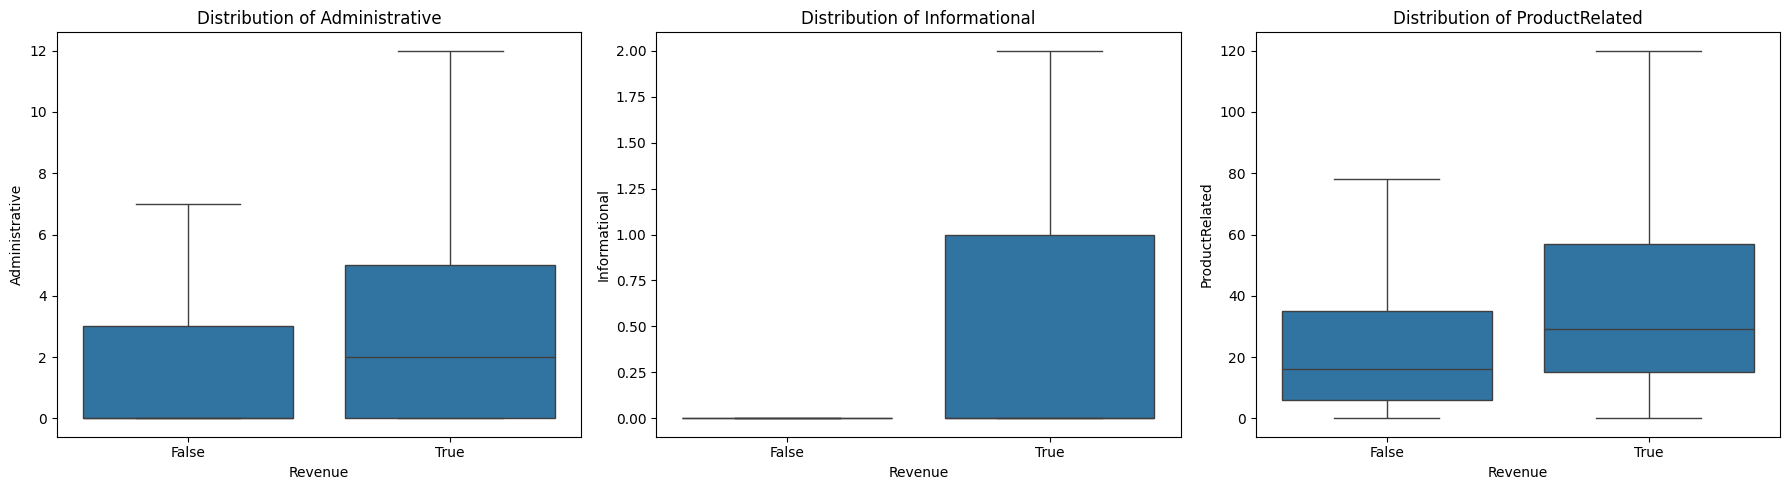

In [21]:
behavioral_features = ['Administrative', 'Informational', 'ProductRelated']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(behavioral_features):
    sns.boxplot(x='Revenue', y=feature, data=df, ax=axes[i], showfliers=False)
    axes[i].set_title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

###Feature Engineering

In [22]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,PageValue_Binary
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,0
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,0
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,0


In [25]:
def engineer_behavioral_features(df):
  df_engineered = df.assign(
      Admin_Ratio = df['Administrative'] / (df['Administrative'] + df['ProductRelated'] + df['Informational'] + 1),
      Info_Ratio =  df['Informational'] / (df['Administrative'] + df['ProductRelated'] + df['Informational'] + 1),
      Product_Efficiency = df['ProductRelated_Duration'] / (df['ProductRelated'] + 1),
      Is_High_Urgency = df['SpecialDay'].apply(lambda x: 1 if x > 0.8 else 0)
  )
  return df_engineered

In [27]:
df_final = engineer_behavioral_features(df)

In [29]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_features = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues',
    'SpecialDay', 'Admin_Ratio', 'Info_Ratio',
    'Product_Efficiency'
]
cat_features = [
    'Month',
    'VisitorType',
    'OperatingSystems',
    'Browser',
    'Region',
    'TrafficType'
]
bin_features = [
    'Weekend',
    'Is_High_Urgency'
]

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)

model = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(
            n_estimators=100,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

In [35]:
X = df_final.drop('Revenue', axis=1)
y = df_final['Revenue']


In [36]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [37]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Administrative',
                                                   'Administrative_Duration',
                                                   'Informational',
                                                   'Informational_Duration',
                                                   'ProductRelated',
                                                   'ProductRelated_Duration',
                                                   'BounceRates', 'ExitRates',
                                                   'PageValues', 'SpecialDay',
                                                   'Admin_Ratio', 'Info_Ratio',
                                                   'Product_Efficiency']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Month', 'VisitorType',
                                                   'OperatingSystems',
                                                   'Browser', 'Region',
                                                   'TrafficType']),
                                                 ('bin', 'passthrough',
                                                  ['Weekend',
                                                   'Is_High_Urgency'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [42]:
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

       False       0.90      0.97      0.93      2055
        True       0.78      0.45      0.57       411

    accuracy                           0.89      2466
   macro avg       0.84      0.71      0.75      2466
weighted avg       0.88      0.89      0.87      2466

ROC-AUC Score: 0.9175


In [45]:
from sklearn.metrics import precision_recall_curve

# Get the probabilities
y_probs = model.predict_proba(X_test)[:, 1]

# Apply a custom threshold of 0.3 instead of 0.5
y_pred_new = (y_probs >= 0.3).astype(int)

print("--- Revised Report (Threshold = 0.3) ---")
print(classification_report(y_test, y_pred_new))

--- Revised Report (Threshold = 0.3) ---
              precision    recall  f1-score   support

       False       0.94      0.92      0.93      2055
        True       0.63      0.73      0.68       411

    accuracy                           0.88      2466
   macro avg       0.79      0.82      0.80      2466
weighted avg       0.89      0.88      0.89      2466



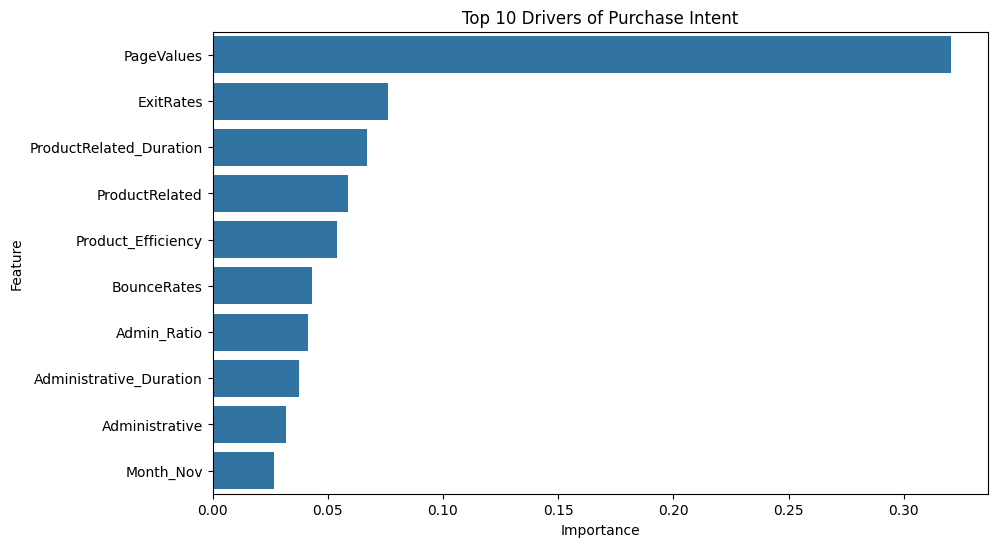

In [47]:
# Extract feature names from the pipeline
ohe_feature_names = model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_features)
all_feature_names = num_features + list(ohe_feature_names) + bin_features

# Get importances
importances = model.named_steps['classifier'].feature_importances_

# Create a DataFrame for visualization
feat_imp_df = pd.DataFrame({'Feature': all_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the top 10
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df.head(10))
plt.title('Top 10 Drivers of Purchase Intent')
plt.show()